In [ ]:
pip install qeds

     |████████████████████████████████| 235kB 4.7MB/s 
  Created wheel for qeds: filename=qeds-0.7.0-cp37-none-any.whl size=27812 sha256=e7de649f51ab6cbf11b130c664de0959f59046e27d9c20c48aa811f76fc1416c
  Stored in directory: /root/.cache/pip/wheels/39/c9/24/c025651bbe9ce3298631f6f7d933c3f8c61b1d50b720762f9d
Successfully built qeds


In [ ]:
import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import pandas_datareader.data as web

from sklearn import (    linear_model, metrics, neural_network, pipeline, preprocessing, model_selection)

import matplotlib.pyplot as plt
%matplotlib inline
# activate plot theme
import qeds
qeds.themes.mpl_style();

In [ ]:
x = np.linspace(-5, 5, 100)
y = 1/(1+np.exp(-x)) #L(x)=1/(1+exp(-x))=exp(x)/(1+exp(x))
plt.plot(x, y)

Trong ví dụ về này, chúng ta dự đoán liệu một cá nhân có phạm tội khác hay không bằng cách sử dụng kết hợp điểm COMPAS được chỉ định và giới tính hoặc chủng tộc của cá nhân đó.

In [ ]:
data_ur="https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
df = pd.read_csv(data_url)
df.head()

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.0,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.0,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.0,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.0,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.0,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.0,F,Possession of Cocaine,1,13011511MM10A,(M1),0.0,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.0,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.0,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [ ]:
df = pd.read_csv(data_url)
df.head()

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.0,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.0,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.0,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.0,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.0,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.0,F,Possession of Cocaine,1,13011511MM10A,(M1),0.0,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.0,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.0,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [ ]:
X = df[["decile_score"]]
y = df["two_year_recid"]
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2)

data=[X_train,y_train]

In [ ]:
import matplotlib.pyplot as plt
#
fig = plt.figure(figsize = (10, 8))
_ = fig.add_subplot(2, 1, 1).scatter(X, y, edgecolor = "red", color = "None")
_ = plt.xlabel("X")

In [ ]:
logistic_model = linear_model.LogisticRegression(solver="lbfgs")
logistic_model.fit(X_train, y_train)

beta_0 = logistic_model.intercept_[0]
beta_1 = logistic_model.coef_[0][0]

print(f"Fit model: p(recid) = L({beta_0:.4f} + {beta_1:.4f} decile_score)")

Fit model: p(recid) = L(-1.3930 + 0.2637 decile_score)


In [ ]:
X = df[["decile_score", "age"]]
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, test_size=0.25, random_state=42
)

logistic_age_model = linear_model.LogisticRegression(solver="lbfgs")
logistic_age_model.fit(X_train, y_train)

beta_0 = logistic_age_model.intercept_[0]
beta_1, beta_2 = logistic_age_model.coef_[0]

print(f"Fit model: p(recid) = L({beta_0:.4f} + {beta_1:.4f} decile_score  {beta_2:.4f} age)")

Fit model: p(recid) = L(-0.8505 + 0.2470 decile_score  -0.0130 age)


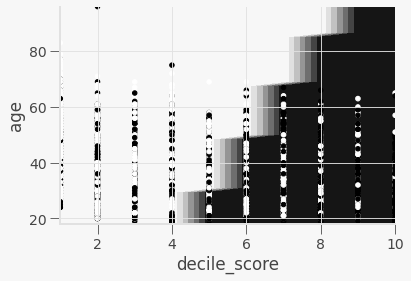

In [ ]:
def plot_contours(ax, mod, xx, yy, **params):
    """
    Plot the decision boundaries for a classifier with 2 features x and y.

    Parameters
    ----------
    ax: matplotlib axes object
    mod: a classifier
    xx: meshgrid ndarray
    yy: meshgrid ndarray
    params: dictionary of params to pass to contourf, optional
    """
    Z = mod.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out

def fit_and_plot_decision_boundary(mod, X, y, **params):
    # fit model
    mod.fit(X, y)

    # generate grids of first two columns of X
    def gen_grid(xseries):
        if xseries.nunique() < 50:
            return sorted(xseries.unique())
        else:
            return np.linspace(xseries.min(), xseries.max(), 50)

    x1, x2 = np.meshgrid(gen_grid(X.iloc[:, 0]), gen_grid(X.iloc[:, 1]))

    # plot contours and scatter
    fig, ax = plt.subplots()
    plot_contours(ax, mod, x1, x2, **params)
    x1_name, x2_name = list(X)[:2]
    X.plot.scatter(x=x1_name, y=x2_name, color=y, ax=ax)
    ax.set_xlabel(x1_name)
    ax.set_ylabel(x2_name)

    return ax

fit_and_plot_decision_boundary(
    linear_model.LogisticRegression(solver="lbfgs"),
    X_train, y_train, cmap=plt.cm.Greys)

In [ ]:
train_acc = logistic_age_model.score(X_train, y_train)
test_acc = logistic_age_model.score(X_test, y_test)

train_acc, test_acc

(0.6534195933456562, 0.667960088691796)

In [ ]:
report = metrics.classification_report(
    y_train, logistic_age_model.predict(X_train),
    target_names=["no recid", "recid"])
print(report)

              precision    recall  f1-score   support

    no recid       0.67      0.73      0.69      2940
       recid       0.64      0.57      0.60      2470

    accuracy                           0.65      5410
   macro avg       0.65      0.65      0.65      5410
weighted avg       0.65      0.65      0.65      5410



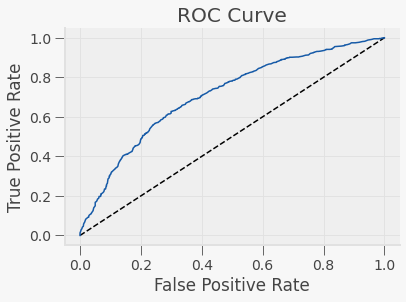

In [ ]:
def plot_roc(mod, X, y):
    # predicted_probs is an N x 2 array, where N is number of observations
    # and 2 is number of classes
    predicted_probs = mod.predict_proba(X_test)

    # keep the second column, for label=1
    predicted_prob1 = predicted_probs[:, 1]

    fpr, tpr, _ = metrics.roc_curve(y_test, predicted_prob1)

    # Plot ROC curve
    fig, ax = plt.subplots()
    ax.plot([0, 1], [0, 1], "k--")
    ax.plot(fpr, tpr)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve")

plot_roc(logistic_age_model, X_test, y_test)

In [ ]:
start = "1974-01-01"
end = datetime.date.today()

def pct_change_on_last_year(df):
    "compute pct_change on previous year, assuming quarterly"
    return (df - df.shift(4))/df.shift(4)

def get_indicators_from_fred(start=start, end=end):
    """
    Fetch quarterly data on 6 leading indicators from time period start:end
    """
    # yield curve, unemployment, change in inventory, new private housing permits
    yc_unemp_inv_permit = (
        web.DataReader(["T10Y2Y", "UNRATE", "CBIC1", "PERMIT"], "fred", start, end)
        .resample("QS")
        .mean()
    )

    # percent change in housing prices and retail sales
    hpi_retail = (
        web.DataReader(["USSTHPI", "SLRTTO01USQ661S"], "fred", start, end)
        .resample("QS")  # already quarterly, adjusting so index is same
        .mean()
        .pipe(pct_change_on_last_year)
        .dropna()
    )

    indicators = (
        yc_unemp_inv_permit
        .join(hpi_retail)
        .dropna()
        .rename(columns=dict(
            USSTHPI="pct_change_hpi",
            T10Y2Y="yield_curve",
            UNRATE="unemp",
            CBIC1="inventory",
            SLRTTO01USQ661S="retail_sales",
            PERMIT="house_permits"
        ))
    )

    return indicators

indicators = get_indicators_from_fred()

indicators.head()

,yield_curve,unemp,inventory,house_permits,pct_change_hpi,retail_sales
DATE,,,,,,
1976-04-01,0.801364,7.566667,61.087,1171.333333,0.075583,0.056936
1976-07-01,1.099688,7.733333,55.190,1345.000000,0.087582,0.037207
1976-10-01,1.467377,7.766667,20.163,1489.000000,0.081407,0.047523
1977-01-01,1.332222,7.500000,34.343,1562.000000,0.104895,0.037939
1977-04-01,1.248254,7.133333,51.245,1693.333333,0.110296,0.032931


In [ ]:
indicators

,yield_curve,unemp,inventory,house_permits,pct_change_hpi,retail_sales
DATE,,,,,,
1976-04-01,0.801364,7.566667,61.087,1171.333333,0.075583,0.056936
1976-07-01,1.099688,7.733333,55.190,1345.000000,0.087582,0.037207
1976-10-01,1.467377,7.766667,20.163,1489.000000,0.081407,0.047523
1977-01-01,1.332222,7.500000,34.343,1562.000000,0.104895,0.037939
1977-04-01,1.248254,7.133333,51.245,1693.333333,0.110296,0.032931
...,...,...,...,...,...,...
2017-04-01,0.963333,4.400000,0.637,1265.333333,0.058415,0.022948
2017-07-01,0.878730,4.300000,56.087,1278.333333,0.056396,0.024696
2017-10-01,0.677097,4.133333,25.302,1319.000000,0.056903,0.037249


In [ ]:
def get_recession_data():
    recession = (
        web.DataReader(["USRECQ"], "fred", start, end)
        .rename(columns=dict(USRECQ="recession"))
        ["recession"]
    )

    # extract start and end date for each recession
    start_dates = recession.loc[recession.diff() > 0].index.tolist()
    if recession.iloc[0] > 0:
        start_dates = [recession.index[0]] + start_dates

    end_dates = recession.loc[recession.diff() < 0].index.tolist()

    #if len(start_dates) != len(end_dates):
        #raise ValueError("Need to have same number of start/end dates!")

    return recession, start_dates, end_dates

recession, start_dates, end_dates = get_recession_data()

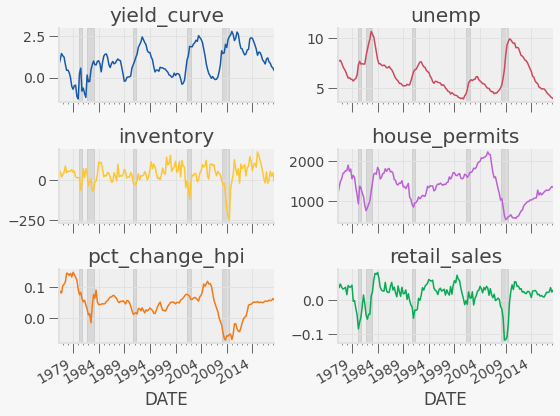

In [ ]:
def add_recession_bands(ax):
    for s, e in zip(start_dates, end_dates):
        ax.axvspan(s, e, color="grey", alpha=0.2)

axs = indicators.plot(subplots=True, figsize=(8, 6), layout=(3, 2), legend=False)

for i, ax in enumerate(axs.flatten()):
    add_recession_bands(ax)
    ax.set_title(list(indicators)[i])

fig = axs[0, 0].get_figure()
fig.tight_layout();

In [ ]:
def make_train_data(indicators, rec, nlead=4):
    return indicators.join(rec.shift(nlead)).dropna()

def fit_for_nlead(ind, rec, nlead, mod):
    df = make_train_data(ind, rec, nlead)
    X = df.drop(["recession"], axis=1).copy()
    y = df["recession"].copy()

    X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y)

    mod.fit(X_train, y_train)
    cmat = metrics.confusion_matrix(y_test, mod.predict(X_test))
    return cmat

mod = pipeline.make_pipeline(
    preprocessing.StandardScaler(),
    linear_model.LogisticRegression(solver="lbfgs")
)

cmats = dict()
for nlead in range(1, 11):
    cmats[nlead] = np.zeros((2, 2))
    print(f"starting for {nlead} leads")
    for rep in range(200):
        cmats[nlead] += fit_for_nlead(indicators, recession, nlead, mod)

    cmats[nlead] = cmats[nlead] / 200

for k, v in cmats.items():
    print(f"\n\nThe average confusion matrix for {k} lag(s) was:\n {v}")

starting for 1 leads
starting for 2 leads
starting for 3 leads
starting for 4 leads
starting for 5 leads
starting for 6 leads
starting for 7 leads
starting for 8 leads
starting for 9 leads
starting for 10 leads


The average confusion matrix for 1 lag(s) was:
 [[37.825  0.805]
 [ 1.695  3.32 ]]


The average confusion matrix for 2 lag(s) was:
 [[37.8    0.705]
 [ 2.25   2.245]]


The average confusion matrix for 3 lag(s) was:
 [[37.715  0.625]
 [ 2.65   2.01 ]]


The average confusion matrix for 4 lag(s) was:
 [[38.065  0.445]
 [ 2.635  1.855]]


The average confusion matrix for 5 lag(s) was:
 [[37.095  0.865]
 [ 3.6    1.44 ]]


The average confusion matrix for 6 lag(s) was:
 [[36.81   1.255]
 [ 3.57   1.365]]


The average confusion matrix for 7 lag(s) was:
 [[36.56   1.255]
 [ 3.48   1.705]]


The average confusion matrix for 8 lag(s) was:
 [[35.98   1.24 ]
 [ 3.735  2.045]]


The average confusion matrix for 9 lag(s) was:
 [[35.64   1.57 ]
 [ 4.155  1.635]]


The average confusion 

In [ ]:
mod

Pipeline(memory=None,
         steps=[('standardscaler',
                 StandardScaler(copy=True, with_mean=True, with_std=True)),
                ('logisticregression',
                 LogisticRegression(C=1.0, class_weight=None, dual=False,
                                    fit_intercept=True, intercept_scaling=1,
                                    l1_ratio=None, max_iter=100,
                                    multi_class='auto', n_jobs=None,
                                    penalty='l2', random_state=None,
                                    solver='lbfgs', tol=0.0001, verbose=0,
                                    warm_start=False))],
         verbose=False)

In [ ]:
%%capture
!pip install quandl 
import quandl 

In [ ]:
# Get US national monthly unadjusted unemployment rate data 
quandl.ApiConfig.api_key = '2BYtKNrxRuVRhzkA9_2s'
unrate_us = quandl.get('FRED/UNRATE', start_date='2010-01-01', end_date='2019-04-01')
unrate_us.columns = ["US"]
unrate_us.index = unrate_us.index.strftime("%Y-%m")

In [ ]:
# Second, we get the monthly state unemployment data 
codes_states = ['01', '02', '04', '05', '06', '08', '09', '10', '11', '12',
              '13', '15', '16', '17', '18', '19', '20', '21', '22', '23',
              '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', 
              '34', '35', '36', '37', '38', '39', '40', '41', '42', '44', 
              '45', '46', '47', '48', '49', '50', '51', '53', '54', '55', 
               '56']
list_states = ("Alabama, Alaska, Arizona, Arkansas, California, "
       "Colorado, Connecticut, Delaware, District of Columbia, "
       "Florida, Georgia, Hawaii, Idaho, Illinois, Indiana, Iowa, "
       "Kansas, Kentucky, Louisiana, Maine, Maryland, Massachusetts, "
       "Michigan, Minnesota, Mississippi, Missouri, Montana, Nebraska, "
       "Nevada, New Hampshire, New Jersey, New Mexico, New York, North Carolina, "
       "North Dakota, Ohio, Oklahoma, Oregon, Pennsylvania, Rhode Island, "
       "South Carolina, South Dakota, Tennessee, Texas, Utah, Vermont, Virginia, "
       "Washington, West Virginia, Wisconsin, Wyoming").split(", ")

api_codes = ['BLSE/LAUST{}0000000000003'.format(x) for x in codes_states]
quandl.ApiConfig.api_key = '2BYtKNrxRuVRhzkA9_2s'
unrate_states = quandl.get(api_codes, start_date='2004-01-01', end_date='2019-04-01')
unrate_states.columns = list_states
unrate_states.index = unrate_states.index.strftime("%Y-%m")

In [ ]:
# Merge the two datasets
unrate = unrate_us.merge(unrate_states, left_index = True, right_index = True)
unrate.tail()


,US,Alabama,Alaska,Arizona,Arkansas,California,Colorado,Connecticut,Delaware,District of Columbia,Florida,Georgia,Hawaii,Idaho,Illinois,Indiana,Iowa,Kansas,Kentucky,Louisiana,Maine,Maryland,Massachusetts,Michigan,Minnesota,Mississippi,Missouri,Montana,Nebraska,Nevada,New Hampshire,New Jersey,New Mexico,New York,North Carolina,North Dakota,Ohio,Oklahoma,Oregon,Pennsylvania,Rhode Island,South Carolina,South Dakota,Tennessee,Texas,Utah,Vermont,Virginia,Washington,West Virginia,Wisconsin,Wyoming
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-11,3.8,3.3,5.6,4.6,3.1,4.0,2.9,3.0,2.9,5.1,3.3,3.5,2.6,2.6,4.0,3.3,2.0,2.9,3.4,4.3,2.9,3.3,2.8,3.5,2.5,4.5,2.6,3.4,2.4,4.0,2.3,3.1,4.7,3.5,3.8,1.9,4.0,2.9,3.7,3.9,3.7,3.0,2.6,3.1,3.5,2.5,2.0,2.6,4.2,4.4,2.6,3.8
2018-12,3.9,3.5,6.1,4.9,3.5,4.2,3.0,3.2,3.1,5.5,3.4,3.8,2.5,2.9,4.4,3.2,2.8,3.0,3.8,4.2,2.9,3.4,3.0,3.9,3.4,5.1,3.0,3.9,2.8,4.2,2.4,3.3,4.9,3.9,3.9,2.3,4.4,3.0,4.0,4.0,3.7,3.2,3.0,3.1,3.6,2.6,2.1,2.6,4.7,4.8,2.8,3.9
2019-01,4.0,4.3,6.8,5.4,4.4,4.9,3.4,4.5,4.1,6.6,3.8,4.3,2.9,3.9,5.4,4.0,3.6,3.7,4.7,5.2,3.7,4.3,4.0,4.8,4.2,5.7,3.7,4.8,3.6,4.7,3.2,4.2,5.5,4.6,4.3,3.2,5.3,3.7,4.6,4.8,4.7,3.8,3.5,3.9,4.2,3.1,2.9,3.4,5.2,6.1,3.4,4.5
2019-02,3.8,3.8,6.3,4.8,4.1,4.4,3.1,4.1,3.7,6.0,3.3,3.9,2.6,3.5,4.9,3.8,3.1,3.5,4.6,4.2,3.5,3.9,3.6,4.6,3.9,5.5,3.7,4.3,3.3,4.2,3.1,4.0,5.3,4.5,4.0,3.0,4.8,3.3,4.3,4.7,4.3,3.4,3.5,3.5,3.8,3.0,2.4,3.1,5.2,6.1,3.5,3.9
2019-03,3.8,3.5,6.2,4.9,3.5,4.5,2.9,3.9,3.6,5.6,3.2,3.7,2.5,3.3,4.6,3.6,3.3,3.4,4.7,4.0,3.2,3.6,3.4,4.8,3.9,5.2,3.6,4.4,3.3,4.1,3.0,3.6,4.9,4.1,3.9,3.0,4.3,3.1,4.4,4.5,3.9,3.3,3.5,3.4,3.5,2.9,2.5,2.9,4.8,5.5,3.6,4.0


In [ ]:
# API library retrieved from: https://github.com/GeneralMills/pytrends
%%capture
!pip install pytrends # --upgrade #--user git+https://github.com/GeneralMills/pytrends
from pytrends.request import TrendReq
pytrends = TrendReq(hl='en-US', tz=360)

In [ ]:
# I use the top 5 most popular terms (extracted from the list of 13 most
# searched Google phrases as shows in Tuhkuri(2016) )

keywords = ('unemployment benefits, unemployment office, '
            'unemployment compensation, unemployment insurance, '
            'unemployment eligibility').split(', ')

pytrends.build_payload(kw_list = keywords, geo = 'US', timeframe = '2010-01-01 2019-01-31')
us = pytrends.interest_over_time()
us_mean = us.mean(axis = 1)
us_mean = us_mean.to_frame(name = 'US')

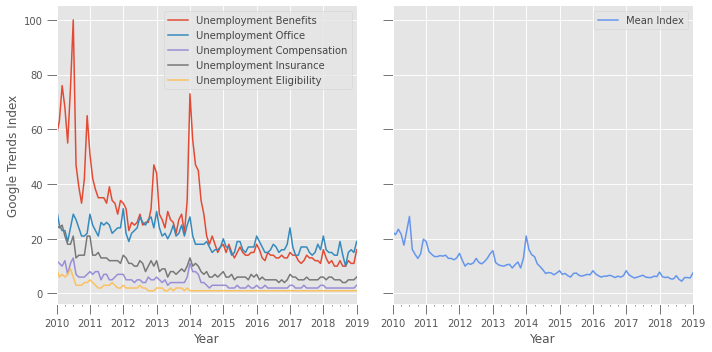

In [ ]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (10,5), sharey = True)
us.plot(ax = ax[0])
us_mean.plot(ax = ax[1], label = 'Mean Index', color = 'cornflowerblue')
ax[0].legend(['Unemployment Benefits', 'Unemployment Office', 'Unemployment Compensation',
              'Unemployment Insurance', 'Unemployment Eligibility'])
ax[0].set_ylabel('Google Trends Index')
ax[0].set_xlabel('Year')
ax[1].legend(['Mean Index'])
ax[1].set_xlabel('Year')

plt.tight_layout()

In [ ]:
# Now, I use the mean index for each US state, and merge the time series into one dataset

state_codes = ["AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DC", "DE", "FL", "GA", 
               "HI", "ID", "IL", "IN", "IA", "KS", "KY", "LA", "ME", "MD", 
               "MA", "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH", "NJ", 
               "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI", "SC", 
               "SD", "TN", "TX", "UT", "VT", "VA", "WA", "WV", "WI", "WY"]
state_list = ['US-{}'.format(x) for x in state_codes]

google_index = us_mean 

for i,j in enumerate(state_list):
  pytrends.build_payload(kw_list = keywords, geo = state_list[i], timeframe = '2010-01-01 2019-01-31')
  state = pytrends.interest_over_time()
  state_mean = state.mean(axis = 1)
  state_mean = state_mean.to_frame(name = j)
  google_index = google_index.merge(state_mean, right_index = True, left_index = True)

google_index.columns = ["US"] + list_states 

In [ ]:
# Merge the google index data to the unemployment data 
import pandas as pd
pd.options.display.max_columns = None

data = unrate.merge(google_index, left_index = True, right_index = True)
data.head()

,US_x,Alabama_x,Alaska_x,Arizona_x,Arkansas_x,California_x,Colorado_x,Connecticut_x,Delaware_x,District of Columbia_x,Florida_x,Georgia_x,Hawaii_x,Idaho_x,Illinois_x,Indiana_x,Iowa_x,Kansas_x,Kentucky_x,Louisiana_x,Maine_x,Maryland_x,Massachusetts_x,Michigan_x,Minnesota_x,Mississippi_x,Missouri_x,Montana_x,Nebraska_x,Nevada_x,New Hampshire_x,New Jersey_x,New Mexico_x,New York_x,North Carolina_x,North Dakota_x,Ohio_x,Oklahoma_x,Oregon_x,Pennsylvania_x,Rhode Island_x,South Carolina_x,South Dakota_x,Tennessee_x,Texas_x,Utah_x,Vermont_x,Virginia_x,Washington_x,West Virginia_x,Wisconsin_x,Wyoming_x,US_y,Alabama_y,Alaska_y,Arizona_y,Arkansas_y,California_y,Colorado_y,Connecticut_y,Delaware_y,District of Columbia_y,Florida_y,Georgia_y,Hawaii_y,Idaho_y,Illinois_y,Indiana_y,Iowa_y,Kansas_y,Kentucky_y,Louisiana_y,Maine_y,Maryland_y,Massachusetts_y,Michigan_y,Minnesota_y,Mississippi_y,Missouri_y,Montana_y,Nebraska_y,Nevada_y,New Hampshire_y,New Jersey_y,New Mexico_y,New York_y,North Carolina_y,North Dakota_y,Ohio_y,Oklahoma_y,Oregon_y,Pennsylvania_y,Rhode Island_y,South Carolina_y,South Dakota_y,Tennessee_y,Texas_y,Utah_y,Vermont_y,Virginia_y,Washington_y,West Virginia_y,Wisconsin_y,Wyoming_y
2010-01-01,9.8,12.3,8.9,11.1,9.0,12.7,8.9,9.5,9.3,10.2,11.5,10.9,7.2,10.5,12.2,11.8,7.3,7.7,11.5,8.2,9.2,8.1,9.6,14.4,8.5,11.7,10.3,8.4,5.4,13.5,7.0,10.3,8.1,9.6,12.0,4.8,12.0,7.6,11.9,9.5,12.1,12.4,5.9,11.2,8.6,8.4,7.0,7.9,11.3,9.4,10.1,8.1,22.500000,19.333333,33.333333,16.666667,7.166667,24.333333,18.666667,19.500000,24.500000,23.500000,15.833333,24.833333,12.166667,12.166667,25.333333,13.666667,14.333333,21.666667,15.500000,16.000000,18.666667,27.666667,23.500000,17.666667,25.833333,15.000000,24.833333,38.833333,15.333333,31.666667,16.833333,21.000000,11.000000,19.333333,23.666667,7.000000,18.666667,33.666667,25.833333,26.833333,16.666667,18.833333,31.000000,13.333333,16.500000,20.666667,20.666667,23.166667,20.666667,10.500000,37.833333,17.000000
2010-02-01,9.8,12.1,9.1,10.7,9.0,12.6,8.9,9.5,9.4,9.9,11.2,10.9,6.9,10.4,11.9,11.8,7.1,7.5,11.9,7.2,9.5,8.3,9.2,14.2,8.4,11.3,10.5,8.4,5.3,13.5,6.9,10.3,8.1,9.5,12.0,4.8,11.9,7.6,11.9,9.5,11.9,12.1,5.9,10.8,8.4,8.3,6.9,7.9,11.2,10.0,10.4,7.8,21.500000,23.166667,21.833333,12.500000,22.666667,19.333333,23.333333,10.666667,26.000000,23.166667,12.166667,22.666667,19.333333,25.000000,21.833333,12.000000,18.333333,13.833333,25.000000,18.833333,14.333333,17.500000,25.500000,22.833333,29.333333,8.666667,22.000000,16.500000,26.000000,16.000000,14.166667,21.666667,33.166667,20.166667,21.166667,7.000000,15.666667,20.166667,20.666667,23.333333,14.666667,14.833333,5.333333,15.833333,17.166667,18.833333,20.500000,18.333333,15.333333,21.666667,43.500000,0.000000
2010-03-01,9.9,11.5,8.9,10.4,8.3,12.6,9.1,9.2,9.0,9.5,11.0,10.4,6.9,10.0,11.5,11.6,6.9,7.5,11.0,7.3,9.2,8.1,8.9,14.1,8.6,10.8,10.2,8.4,5.2,13.6,6.7,10.1,8.2,9.1,11.5,4.8,11.4,7.0,11.9,9.2,11.7,11.5,5.9,10.6,8.3,8.4,7.0,7.7,10.9,9.3,10.3,7.6,23.500000,27.666667,0.000000,17.333333,21.333333,21.500000,19.500000,23.833333,21.333333,19.500000,15.666667,23.833333,9.000000,34.500000,24.166667,14.166667,24.000000,22.500000,20.333333,19.000000,20.833333,24.000000,24.666667,22.000000,22.000000,13.000000,19.000000,26.000000,11.833333,15.833333,16.000000,23.666667,15.500000,23.833333,32.166667,0.000000,17.500000,24.500000,23.000000,27.000000,11.666667,15.166667,9.666667,7.833333,18.000000,30.666667,18.000000,19.500000,22.666667,13.333333,29.833333,25.000000
2010-04-01,9.9,10.4,8.3,10.1,7.8,12.0,8.5,8.9,8.5,8.7,10.6,9.9,6.7,9.4,10.5,10.6,5.9,6.9,10.0,7.1,8.5,7.3,8.3,12.9,7.5,9.8,9.3,7.5,4.6,13.4,5.9,9.4,7.9,8.5,10.9,3.8,10.4,6.5,11.0,8.3,11.2,10.9,4.9,9.6,7.9,7.8,6.6,7.0,10.0,8.4,9.0,7.0,21.666667,10.000000,4.000000,11.166667,19.500000,20.500000,17.666667,22.166667,21.000000,14.333333,14.000000,26.833333,15.000000,16.666667,20.166667,15.000000,20.833333,10.833333,19.000000,20.500000,8.500000,21.333333,19.833333,19.333333,16.333333,8.333333,20.666667,21.500000,15.000000,29.5

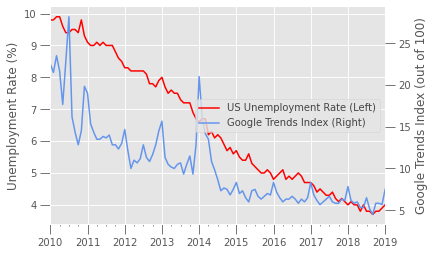

In [ ]:
# Graphically

import matplotlib.pyplot as plt
fig, ax = plt.subplots()
plt.style.use('ggplot')

ax2 = ax.twinx()


data.plot(kind = 'line', y = 'US_x', ax = ax, color = 'red', label='US Unemployment Rate (Left)')
data.plot(kind = 'line', y = 'US_y', ax = ax2, color = 'cornflowerblue', label='Google Trends Index (Right)')

ax.set_ylabel('Unemployment Rate (%)')
ax2.set_ylabel('Google Trends Index (out of 100)')

ax2.grid(None)

'''Legend'''
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.get_legend().remove()
ax.get_legend().remove()
plt.legend(lines + lines2, labels + labels2, loc = 'right')

In [ ]:
# Numerically

corr_vector = []
for i in list_states:
  corr = data['{}_x'.format(i)].corr(data['{}_y'.format(i)])
  corr_vector.append(corr)

corr = pd.Series(corr_vector).to_frame(name = 'Correlation')
c = corr.mean(axis = 0)
print('Mean Correlation between Google Trends Index and State-level Unemployment Rates is: \n', c) 

Mean Correlation between Google Trends Index and State-level Unemployment Rates is: 
 Correlation    0.670178
dtype: float64


In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn import neural_network
from sklearn import metrics

In [ ]:
def model1(lag):
  
  df = data.copy() 
  
  '''Forecast Horizon''' 
  # First, choose the forecast period (1, 2, or 3 months ahead), and lag the US  
  # national unemployment rate by that period

  df['US_x'] = df['US_x'].shift(-lag)
   
  '''Scaling the data'''
  # Notice that I apply the Scaler to the Train and Test data separately 
  scaler = StandardScaler()

  '''Prepare the train data'''
  split_date = pd.Timestamp('2017-01-01')
  train = df.loc[ :split_date] 
  train_clean = train.drop(['US_y']+['{}_y'.format(x) for x in list_states], axis = 1).copy()
  train_sc = scaler.fit_transform(train_clean)
  train_sc = pd.DataFrame(train_sc)
  train_sc['date'] = train.index
  train_sc.set_index('date', inplace = True)
  
  X_train = train_sc.drop([0], axis = 1).copy() 
  y_train = train_sc.drop(list(range(1,52)), axis = 1).copy()

  '''Prepare the test data'''
  test = df.loc[split_date: ]
  test_clean = test.drop(['US_y']+['{}_y'.format(x) for x in list_states], axis = 1).copy()
  test_sc = scaler.fit_transform(test_clean)
  test_sc = pd.DataFrame(test_sc)
  test_sc['date'] = test.index
  test_sc.set_index('date', inplace = True)
  test_sc = test_sc[:-lag]

  X_test = test_sc.drop([0], axis = 1).copy()
  y_test = test_sc.drop(list(range(1,52)), axis = 1).copy()

  '''Parameters for Neural Network'''
  _alpha = 1
  _activation = "logistic"
  _max_iter = 10000
  _solver = 'lbfgs'

  '''Fitting the MLP model'''
  nn_model = neural_network.MLPRegressor((50, 50), activation = _activation, 
                                         solver = _solver, alpha = _alpha,  max_iter = _max_iter)
  
  return (nn_model, X_train, y_train, X_test, y_test)

In [ ]:
def model1_mse(lag):
  
  nn_model, X_train, y_train, X_test, y_test = model1(lag)
  nn_model.fit(X_train, y_train)
  
  '''View MSE for Train and Test data'''
  mse_train = metrics.mean_squared_error(y_train, nn_model.predict(X_train))
  mse_test = metrics.mean_squared_error(y_test, nn_model.predict(X_test))
  
  return [mse_train, mse_test]

def model1_plt(lag):
  
  nn_model, X_train, y_train, X_test, y_test = model1(lag)
  nn_model.fit(X_train, y_train)
  
  '''Plot the True and Predicted values in the Test data'''
  nn_y_pred_test = nn_model.predict(X_test)
  nn_y_pred_test = pd.DataFrame(nn_y_pred_test)
   
  nn_y_pred_test['date'] = y_test.index
  nn_y_pred_test.set_index('date', inplace = True)
 
  plt.plot(y_test.shift(periods = lag), label = 'True', color = 'red')
  plt.plot(nn_y_pred_test.shift(periods = lag), label = '{}-Month Forecast'.format(lag), 
          color = 'mediumturquoise')

In [ ]:
def model2(lag):
  
  df = data.copy() 
  
  '''Forecast Horizon''' 
  # First, choose the forecast period (1, 2, or 3 months ahead), and lag the US  
  # national unemployment rate by that period

  df['US_x'] = df['US_x'].shift(-lag)
   
  '''Scaling the data'''
  # Notice that I apply the Scaler to the Train and Test data separately 
  scaler = StandardScaler()

  '''Prepare the train data'''
  split_date = pd.Timestamp('2017-01-01')
  train = df.loc[ :split_date] 
  train_clean = train.drop(['US_y'], axis = 1).copy()
  train_sc = scaler.fit_transform(train_clean)
  train_sc = pd.DataFrame(train_sc)
  train_sc['date'] = train.index
  train_sc.set_index('date', inplace = True)

  X_train = train_sc.drop([0], axis = 1).copy() 
  y_train = train_sc.drop(list(range(1,103)), axis = 1).copy()

  '''Prepare the test data'''
  test = df.loc[split_date: ]
  test_clean = test.drop(['US_y'], axis = 1).copy()
  test_sc = scaler.fit_transform(test_clean)
  test_sc = pd.DataFrame(test_sc)
  test_sc['date'] = test.index
  test_sc.set_index('date', inplace = True)
  test_sc = test_sc[:-lag]

  X_test = test_sc.drop([0], axis = 1).copy()
  y_test = test_sc.drop(list(range(1,103)), axis = 1).copy()

  '''Parameters for Neural Network'''
  _alpha = 1
  _activation = "logistic"
  _max_iter = 10000 
  _solver = 'lbfgs'

  '''Fitting the MLP model'''
  nn_model = neural_network.MLPRegressor((50, 50), activation = _activation, 
                                         solver = _solver, alpha = _alpha,  max_iter = _max_iter)
  
  return (nn_model, X_train, y_train, X_test, y_test)

In [ ]:
def model2_mse(lag):
  
  nn_model, X_train, y_train, X_test, y_test = model2(lag)
  nn_model.fit(X_train, y_train)
  
  '''View MSE for Train and Test data'''
  mse_train = metrics.mean_squared_error(y_train, nn_model.predict(X_train))
  mse_test = metrics.mean_squared_error(y_test, nn_model.predict(X_test))
  
  return [mse_train, mse_test]

def model2_plt(lag):
  
  nn_model, X_train, y_train, X_test, y_test = model2(lag)
  nn_model.fit(X_train, y_train)
  
  '''Plot the True and Predicted values in the Test data'''
  nn_y_pred_test = nn_model.predict(X_test)
  nn_y_pred_test = pd.DataFrame(nn_y_pred_test)
   
  nn_y_pred_test['date'] = y_test.index
  nn_y_pred_test.set_index('date', inplace = True)
 
  plt.plot(nn_y_pred_test.shift(periods = lag), label = '{}-Month Forecast - Google Index'.format(lag), 
          color = 'cornflowerblue')

In [ ]:
def model3(lag):
  
  df = data.copy() 
  df = df.drop(['US_y'], axis = 1)

  '''Create data for t-1 and t-2 '''
  df1 = df.shift(1)
  name_col = df1.columns 
  name_col = [s + "_1" for s in name_col]
  df1.columns = name_col
  
  df2 = df.shift(2)
  name_col = df2.columns 
  name_col = [s + "_2" for s in name_col]
  df2.columns = name_col
  
  df = pd.concat([df, df1, df2], axis=1)
  
  '''Forecast Horizon''' 
  # First, choose the forecast period (1, 2, or 3 months ahead), and lag the US  
  # national unemployment rate by that period
  
  df['US_x'] = df['US_x'].shift(-lag)
  df.dropna(axis = 0, inplace = True)
  
  '''Scaling the data'''
  # Notice that I apply the Scaler to the Train and Test data separately 
  scaler = StandardScaler()
  
  '''Prepare the train data'''
  split_date = pd.Timestamp('2017-01-01')
  train = df.loc[ :split_date] 
  train_sc = scaler.fit_transform(train)
  train_sc = pd.DataFrame(train_sc)
  train_sc['date'] = train.index
  train_sc.set_index('date', inplace = True)

  X_train = train_sc.drop([0], axis = 1).copy() 
  y_train = train_sc.drop(list(range(1,309)), axis = 1).copy()

  '''Prepare the test data'''
  test = df.loc[split_date: ]
  test_sc = scaler.fit_transform(test)
  test_sc = pd.DataFrame(test_sc)
  test_sc['date'] = test.index
  test_sc.set_index('date', inplace = True)
  test_sc = test_sc[:-lag]

  X_test = test_sc.drop([0], axis = 1).copy()
  y_test = test_sc.drop(list(range(1,309)), axis = 1).copy()

  '''Parameters for Neural Network'''
  _alpha = 1
  _activation = "logistic"
  _max_iter = 10000 
  _solver = 'lbfgs'

  '''Fitting the MLP model'''
  nn_model = neural_network.MLPRegressor((50, 50), activation = _activation, 
                                         solver = _solver, alpha = _alpha,  max_iter = _max_iter)
  
  return (nn_model, X_train, y_train, X_test, y_test)

In [ ]:
def model3_mse(lag):
  
  nn_model, X_train, y_train, X_test, y_test = model3(lag)
  nn_model.fit(X_train, y_train)
  
  '''View MSE for Train and Test data'''
  mse_train = metrics.mean_squared_error(y_train, nn_model.predict(X_train))
  mse_test = metrics.mean_squared_error(y_test, nn_model.predict(X_test))
  
  return [mse_train, mse_test]

def model3_plt(lag):
  
  nn_model, X_train, y_train, X_test, y_test = model3(lag)
  nn_model.fit(X_train, y_train)
  
  '''Plot the True and Predicted values in the Test data'''
  nn_y_pred_test = nn_model.predict(X_test)
  nn_y_pred_test = pd.DataFrame(nn_y_pred_test)
   
  nn_y_pred_test['date'] = y_test.index
  nn_y_pred_test.set_index('date', inplace = True)
 
  plt.plot(nn_y_pred_test.shift(periods = lag), label = '{}-Month Forecast - Google Index - Past Values'.format(lag), 
          color = 'tab:purple')


In [ ]:
import warnings
warnings.filterwarnings('ignore')

## MSE results 
 
mse_list1 = []
for _lag in range(1,4):
  mse = model1_mse(lag = _lag)
  mse_list1.append(mse)

mse_list1 = pd.DataFrame(mse_list1)
mse_list1.index = ['1-month forecast', '2-month forecast', '3-month forecast']
mse_list1.columns = ['MSE Train', 'MSE Test']
mse_list1

mse_list2 = []
for _lag in range(1,4):
  mse = model2_mse(lag = _lag)
  mse_list2.append(mse)

mse_list2 = pd.DataFrame(mse_list2)
mse_list2.index = ['1-month forecast', '2-month forecast', '3-month forecast']
mse_list2.columns = ['MSE Train', 'MSE Test']

mse_list3 = []
for _lag in range(1,4):
  mse = model3_mse(lag = _lag)
  mse_list3.append(mse)

mse_list3 = pd.DataFrame(mse_list3)
mse_list3.index = ['1-month forecast', '2-month forecast', '3-month forecast']
mse_list3.columns = ['MSE Train', 'MSE Test']

mse = mse_list1.merge(mse_list2, left_index = True, right_index = True)
mse = mse.merge(mse_list3, left_index = True, right_index = True)

models = ['Model1', 'Model2', 'Model3']
mse.columns = pd.MultiIndex.from_product([models, mse_list1.columns])
mse

Model1              Model2              Model3          
                 MSE Train  MSE Test MSE Train  MSE Test MSE Train  MSE Test
1-month forecast  0.022896  0.547658  0.016474  0.510710  0.007914  0.352391
2-month forecast  0.025100  0.686601  0.017378  0.665833  0.007254  0.436168
3-month forecast  0.025089  0.738466  0.016457  0.685098  0.007380  0.400609

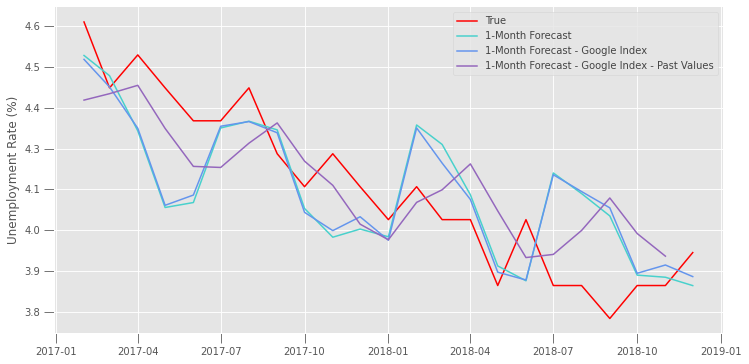

In [ ]:
## One-month forecasts

import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize = (12,6))
model1_plt(lag = 1)
model2_plt(lag = 1)
model3_plt(lag = 1)
ax.legend()
ax.set_ylabel('Unemployment Rate (%)')


ax.set_yticklabels(list(np.round(np.linspace(3.7, 4.7, 10), decimals = 1)))
ax.spines['right'].set_visible(False)

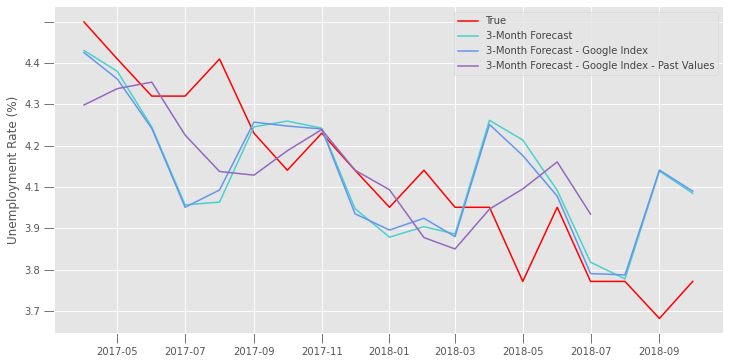

In [ ]:
## Three-month forecasts

import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize = (12,6))
model1_plt(lag = 3)
model2_plt(lag = 3)
model3_plt(lag = 3)

ax.legend()
ax.set_ylabel('Unemployment Rate (%)')

ax.set_yticklabels(list(np.round(np.linspace(3.6, 4.4, 8), decimals = 1)))
ax.spines['right'].set_visible(False)


In [ ]:
pip install iexfinance

     |████████████████████████████████| 61kB 4.2MB/s 


In [ ]:
import pandas as pd
import numpy as np
import iexfinance
from iexfinance.stocks import get_historical_data
from datetime import datetime, date

# start date should be within 5 years of current date according to iex API we have used
# The more data we have, the better results we get!

start = datetime(2016, 1, 1)
end = date.today()
# use your token in place of token which you will get after signing up on IEX cloud
# Head over to https://iexcloud.io/ and sign-up to get your API token
df = get_historical_data("AAPL", start=start, end=end, output_format="pandas", token="your_token")

IEXQueryError: ignored